# Shapefile Selection

When conducting our initial analysis, we noticed that the Shapefile was missing some areas of Berbera Port. Normally this would not be cause for alarm, however we know that Berbera Port has the brightest points in Somaliland, missing even a few squares could potentially distort our results significantly. 

The below code demonstrates the difference between the three shapefiles which we have tested during this analysis. For simplicities sake we have labelled them, Somaliland_Normal for the original shapefile which can be downloaded from (https://gadm.org/download_country.html). The total value of the illumination in Somaliland in 2023 for this code is: 10130 and for Berbera: 1518.

We tested a shapefile where we merged a manually drawn bounding box onto the Somaliland shapefile. We have termed this the Somaliland_Berbera shapefile. The total illumination for Somaliland from this approach was: 10789 and for Berbera 2181.

Finally we tested a shapefile where we extended the borders of Somaliland by 300 metres in all directions, we called this shapefile Somaliland_expanded. The total illumination for Somliland in 2023 from this approach is: 10856 and for Berbera 2209. This shapefile captures approximately 28 additional units of illumination in Berbera and 67 additional units overall. (Implying very little illumination around the border.)

Given the small difference between these values we believe it is appropriate to use either in analysis of Somaliland. For this analysis we chose to use. 


## Important
It is important to note that even small changes in the shapefile used when sending the request to download the VIIRS Blackmarble satelitte data changes the spatial extent of the data. This is even if the bounding box of the shapefile is unchanged. We currently do not understand exactly why this occurs. 

In [1]:
import geopandas as gpd
import xarray as xr
import pandas as pd

#Local Functions
import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box


In [2]:
#Load Somaliland Boundary Shapefiles

gdf = gpd.read_file(
    "../data/Combined_Datasets/gadm41_SOM_1.json.zip"
)
#Somaliland SHP File
somaliland_shp = gdf[gdf["HASC_1"].isin(["SO.AW", "SO.WO", "SO.TO", "SO.SA", "SO.SO"])]

#Phillip Somaliland_SHP
somaliland_shp_berbera = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)

somaliland_shp_expanded = (
    somaliland_shp
    .to_crs(epsg=32638)
    .dissolve()
    .buffer(300)
    .to_crs(epsg=4326)
    .to_frame("geometry")
    .reset_index(drop=True)
)
somaliland_shp_expanded.to_file(
    "../data/Combined_Datasets/Somaliland_Expanded/somaliland_expanded.shp")   

In [4]:
SL_normal = xr.open_dataset("../data/NTL_Data_A4/20251215_SL_VNP46A4_EY_2012_24.nc")
SL_berbera = xr.open_dataset("../data/NTL_Data_A4/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")
SL_expanded = xr.open_dataset("../data/NTL_Data_A4/20251215_SL_Expanded_VNP46A4_EY_2012_24.nc")

In [5]:
#SL_Normal has a smaller bounding box than the others. 
#Expanded & Berbera have SouthBoundingCoord': np.float64(0.0), and 'WestBoundingCoord': np.float64(40.0)
#Normal has 'SouthBoundingCoord': np.float64(10.0), and 'WestBoundingCoord': np.float64(40.0)
print("SL Normal: WestBoundCoord", SL_normal.attrs["WestBoundingCoord"])
print("SL Berbera: WestBoundCoord", SL_berbera.attrs["WestBoundingCoord"])
print("SL Expanded: WestBoundCoord", SL_expanded.attrs["WestBoundingCoord"])

print("SL Normal: SouthBoundCoord", SL_normal.attrs["SouthBoundingCoord"])
print("SL Berbera: SouthBoundCoord", SL_berbera.attrs["SouthBoundingCoord"])
print("SL Expanded: SouthBoundCoord", SL_expanded.attrs["SouthBoundingCoord"])

SL Normal: WestBoundCoord 40.0
SL Berbera: WestBoundCoord 40.0
SL Expanded: WestBoundCoord 40.0
SL Normal: SouthBoundCoord 10.0
SL Berbera: SouthBoundCoord 0.0
SL Expanded: SouthBoundCoord 0.0


In [6]:
print("SL Normal: Time Range", SL_normal.time.min().values, SL_normal.time.max().values)
print("SL Berbera: Time Range", SL_berbera.time.min().values, SL_berbera.time.max().values)
print("SL Expanded: Time Range", SL_expanded.time.min().values, SL_expanded.time.max().values)  

SL Normal: Time Range 2012-01-01T00:00:00.000000000 2023-01-01T00:00:00.000000000
SL Berbera: Time Range 2012-01-01T00:00:00.000000000 2023-01-01T00:00:00.000000000
SL Expanded: Time Range 2012-01-01T00:00:00.000000000 2023-01-01T00:00:00.000000000


In [24]:
print(SL_normal.rio.bounds())
print(SL_berbera.rio.bounds())

print(SL_normal.rio.resolution())
print(SL_berbera.rio.resolution())

(42.704288736979166, 7.9834554036458325, 49.079288736979166, 11.516788736979166)
(42.68345540364584, 7.999975585937501, 49.079288736979166, 11.512518463134768)
(0.004166666666666669, -0.004166666666666667)
(0.004166666666666666, -0.004166717529296876)


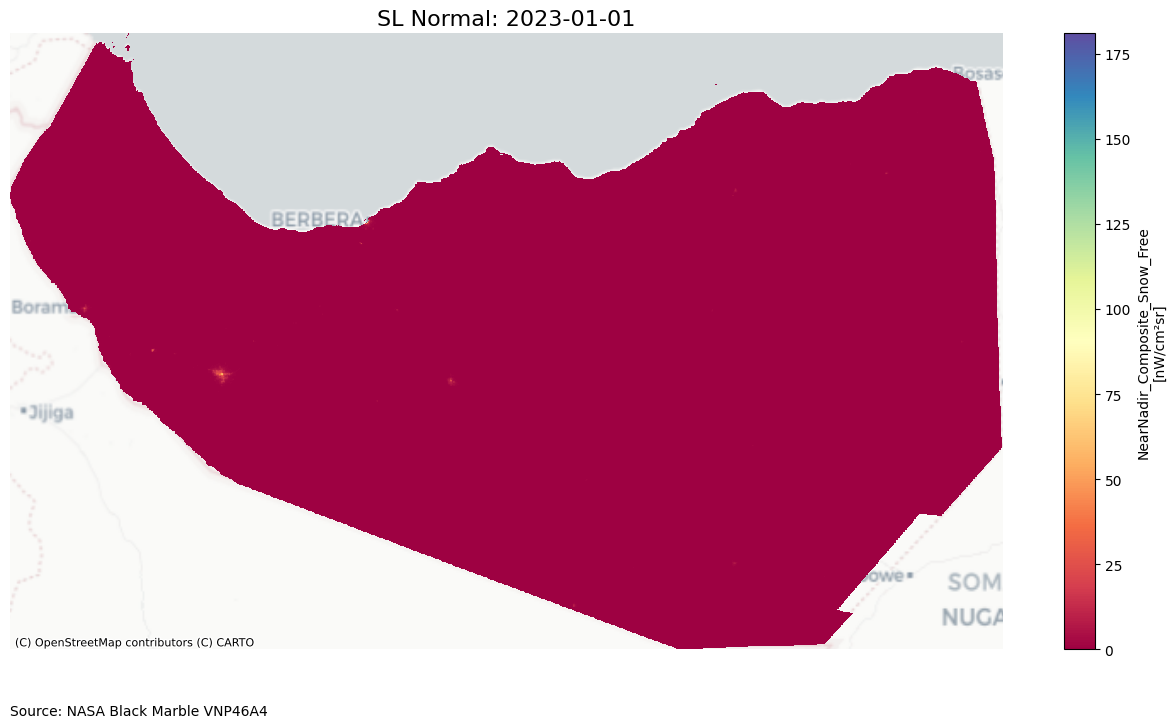

In [7]:
plot_NASA_NTL(SL_normal, somaliland_shp, 
              date="2023-01-01", 
              variable="NearNadir_Composite_Snow_Free", 
              title_prefix="SL Normal",
              robust=False)

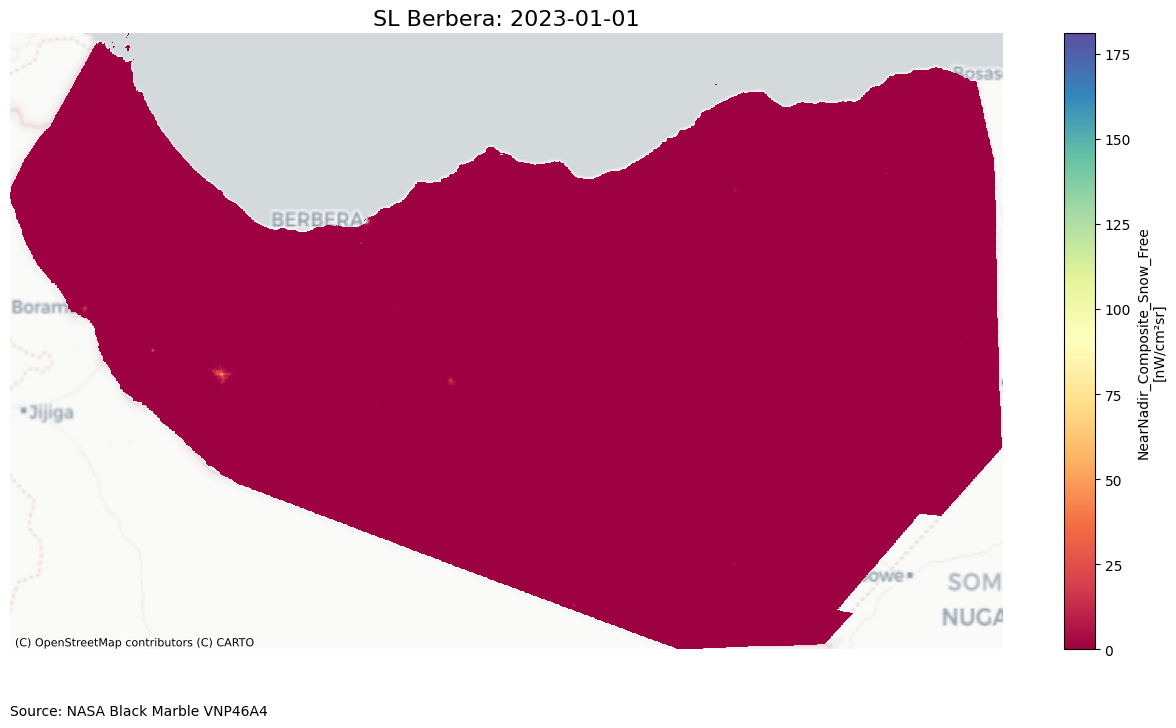

In [8]:
plot_NASA_NTL(SL_normal, somaliland_shp_berbera, 
              date="2023-01-01", 
              variable="NearNadir_Composite_Snow_Free", 
              title_prefix="SL Berbera",
              robust=False)

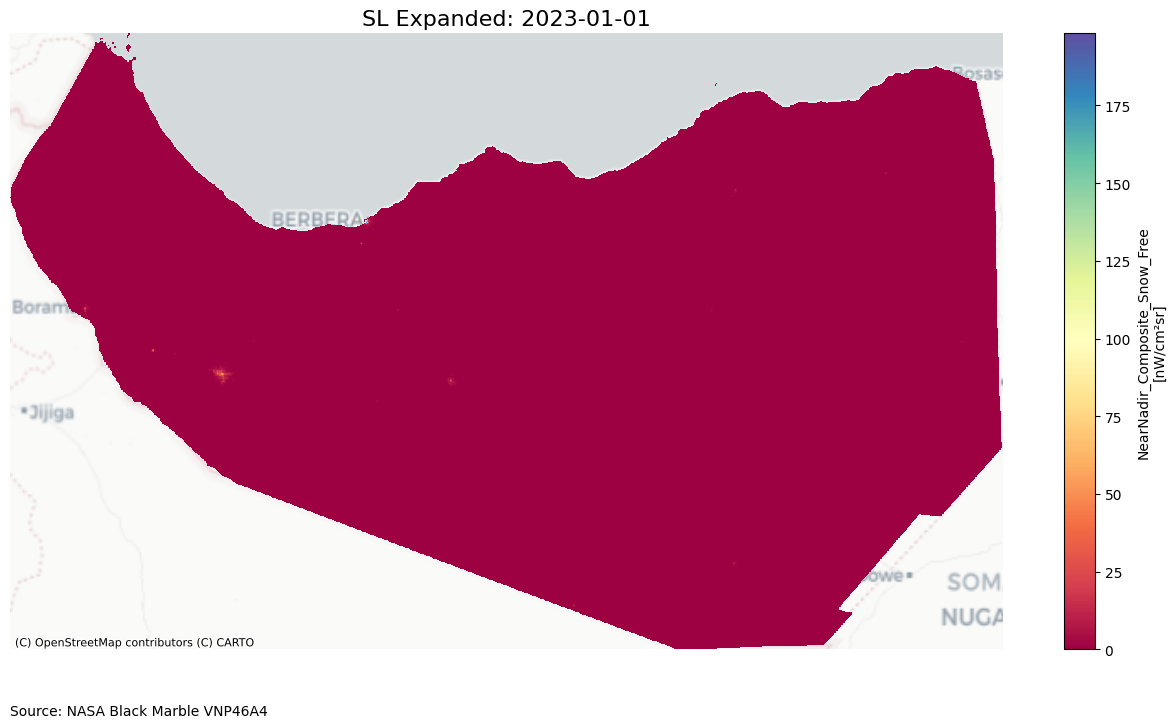

In [9]:
plot_NASA_NTL(SL_expanded, somaliland_shp_expanded, 
              date="2023-01-01", 
              variable="NearNadir_Composite_Snow_Free", 
              title_prefix="SL Expanded",
              robust=False)

In [27]:
def yearly_sums(gdf):
    year = []
    for i in range(2012,2024):
        year.append(gdf["NearNadir_Composite_Snow_Free"].sel(time=f"{i}-01-01").sum().item())
    return year

sl_normal_totalr = yearly_sums(SL_normal)
sl_berbera_totalr = yearly_sums(SL_berbera)
sl_expanded_totalr = yearly_sums(SL_expanded)

df = pd.DataFrame({
    "Year": list(range(2012, 2024)),
    "SL Normal":sl_normal_totalr, 
    "SL Berbera":sl_berbera_totalr,
    "SL Expanded": sl_expanded_totalr})

df

,Year,SL Normal,SL Berbera,SL Expanded
0,2012,1685.472030,1724.642974,1727.862770
1,2013,1750.362238,1787.334167,1788.347952
2,2014,1923.084363,1956.063639,1960.702678
3,2015,2126.797759,2165.440765,2169.916363
4,2016,2288.289691,2328.560843,2335.446844
5,2017,2692.186382,2740.706297,2746.151578
6,2018,3421.317992,3516.255303,3529.021586
7,2019,4204.155284,4322.614680,4337.872349
8,2020,5470.240536,5641.465840,5667.636581
9,2021,7475.877504,7800.542518,7854.130744


In [11]:
#Cities
HGA = gpd.read_file("../data/Combined_Datasets/Hargeisa_shp/HGA.shp")
Berbera = gpd.read_file("../data/Combined_Datasets/Berbera_shp/Berbera.shp")
Burao = gpd.read_file("../data/Combined_Datasets/Burao_shp/Burao.shp")
Boroma = gpd.read_file("../data/Combined_Datasets/Boroma_shp/Boroma.shp")
Erigavo = gpd.read_file("../data/Combined_Datasets/Erigavo_shp/Erigavo.shp")
Las_Anod = gpd.read_file("../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp")

# For graphing
normal_Berbera_NTL = filter_dataset_by_bounding_box(SL_normal, Berbera)
Berbera_Berbera_NTL = filter_dataset_by_bounding_box(SL_berbera, Berbera)
expanded_Berbera_NTL = filter_dataset_by_bounding_box(SL_expanded, Berbera)



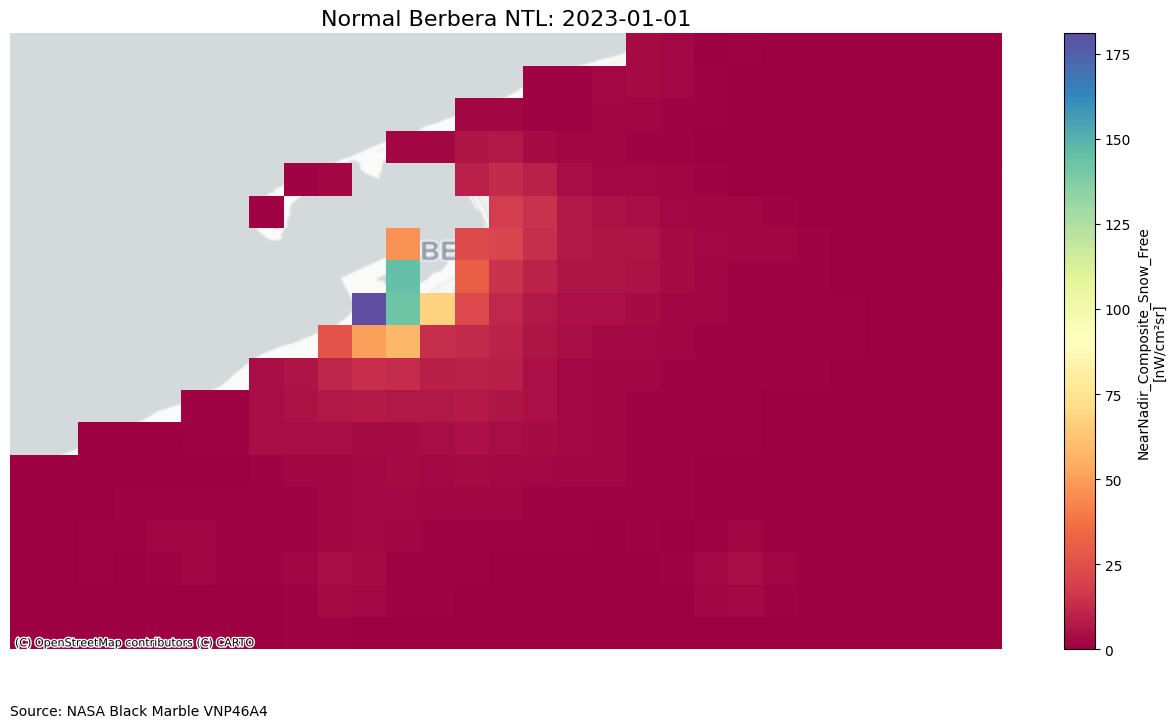

In [12]:
plot_NASA_NTL(normal_Berbera_NTL, Berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Normal Berbera NTL", robust=False)

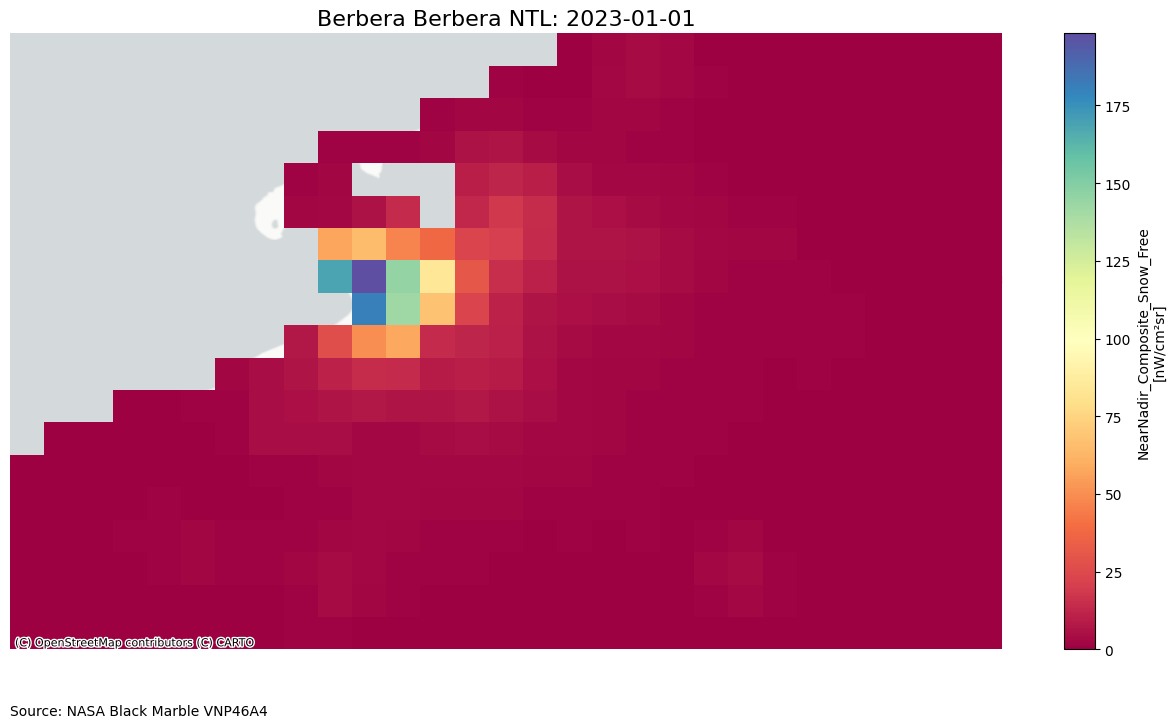

In [13]:
plot_NASA_NTL(Berbera_Berbera_NTL, Berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Berbera Berbera NTL", robust=False)

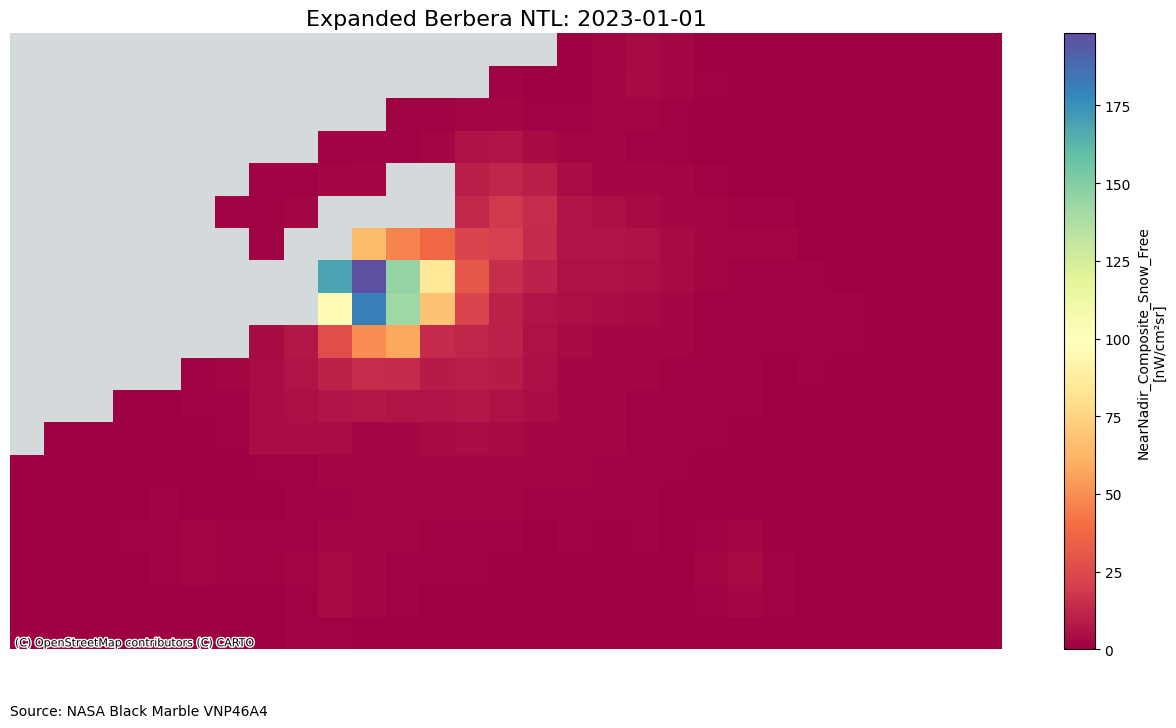

In [14]:
plot_NASA_NTL(expanded_Berbera_NTL, Berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Expanded Berbera NTL", robust=False)

In [23]:
print(SL_expanded["NearNadir_Composite_Snow_Free"].sel(time="2023").max())
print(SL_berbera["NearNadir_Composite_Snow_Free"].sel(time="2023").max())
print(SL_normal["NearNadir_Composite_Snow_Free"].sel(time="2023").max())

<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(198.18493652)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref
<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(198.18493652)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref
<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(180.96917725)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref


In [26]:
berbera_normal_totalr = yearly_sums(normal_Berbera_NTL)
berbera_berbera_totalr = yearly_sums(Berbera_Berbera_NTL)
berbera_expanded_totalr = yearly_sums(expanded_Berbera_NTL)

df_berbera = pd.DataFrame({
    "Year": list(range(2012, 2024)),
    "Berbera Normal":berbera_normal_totalr, 
    "Berbera Berbera":berbera_berbera_totalr,
    "Berbera Expanded": berbera_expanded_totalr})

df_berbera

,Year,Berbera Normal,Berbera Berbera,Berbera Expanded
0,2012,204.326788,243.366427,241.820795
1,2013,225.544435,262.564428,259.687815
2,2014,214.856975,248.637273,247.040110
3,2015,228.932852,266.845144,264.274654
4,2016,244.065501,284.283806,281.814134
5,2017,269.268525,314.112247,312.060440
6,2018,404.175709,495.908442,493.396898
7,2019,466.116501,586.830692,581.566079
8,2020,602.789170,777.077849,773.764273
9,2021,1018.085156,1348.254389,1359.112356


(42.704288736979166, 7.9834554036458325, 49.079288736979166, 11.516788736979166)
(42.68345540364584, 7.999975585937501, 49.079288736979166, 11.512518463134768)
(0.004166666666666669, -0.004166666666666667)
(0.004166666666666666, -0.004166717529296876)


<xarray.Dataset> Size: 249MB
Dimensions:                        (x: 1535, y: 1691, time: 12)
Coordinates:
  * x                              (x) float64 12kB 42.69 42.69 ... 49.07 49.08
  * y                              (y) float64 14kB 7.986 7.99 ... 11.51 11.51
  * time                           (time) datetime64[ns] 96B 2012-01-01 ... 2...
Data variables:
    NearNadir_Composite_Snow_Free  (time, y, x) float64 249MB nan nan ... nan
Attributes: (12/42)
    AlgorithmType:                     b'SCI'
    AlgorithmVersion:                  b'NPP_PR46A3 2.0.0'
    Conventions:                       b'CF-1.6'
    creator_email:                     b'modis-ops@lists.nasa.gov'
    creator_name:                      b'VIIRS Land SIPS Processing Group'
    creator_url:                       b'https://ladsweb.modaps.eosdis.nasa.gov'
    ...                                ...
    VerticalTileNumber:                b'07'
    WestBoundingCoord:                 40.0
    AREA_OR_POINT:                     Area
    scale_factor:                      1.0
    add_offset:                        0.0
    _FillValue:                        nan